# Clasificador de Videojuegos con CNN



In [10]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


base_dir = 'videogames-cnn-dataset_V2'
train_dir = os.path.join(base_dir,'train')
test_dir = os.path.join(base_dir, 'test')

train_datagen = ImageDataGenerator(
							rescale = 1./255,
							rotation_range = 10,
							width_shift_range = 0.2,
						#	height_shift_range = 0.2,
						#	shear_range = 0.3,
							zoom_range = 0.3,
							horizontal_flip = True)

Found 18586 images belonging to 3 classes.


<Figure size 640x480 with 0 Axes>

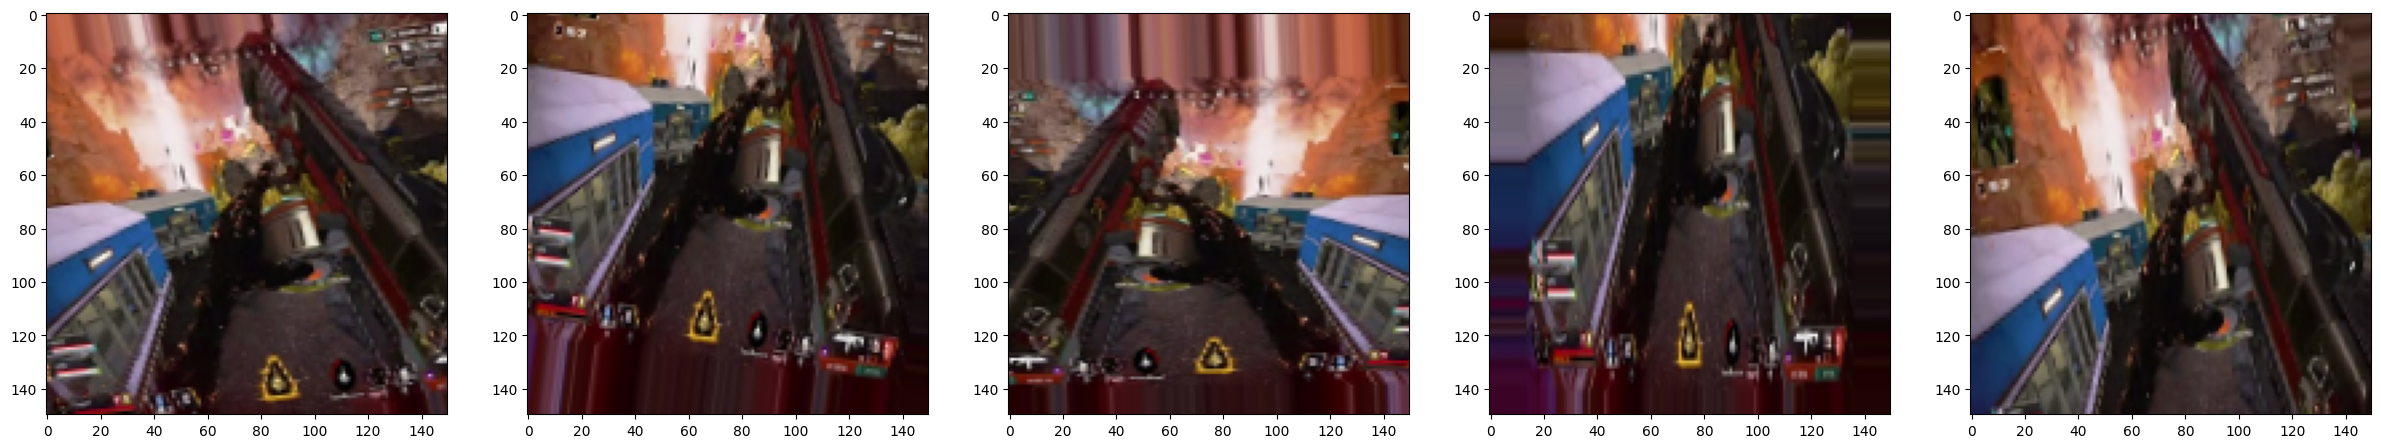

In [11]:
train_generator = train_datagen.flow_from_directory(
							train_dir,
							target_size = (150, 150),
							batch_size = 256,
							class_mode ='categorical',
							)


plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, 5, figsize=(30, 8))

for i in range(5) :
  axarr[i].imshow(train_generator[0][0][0])

Found 18586 images belonging to 3 classes.
(400, 300, 300, 3)
[[0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 ...
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]]


<Figure size 640x480 with 0 Axes>

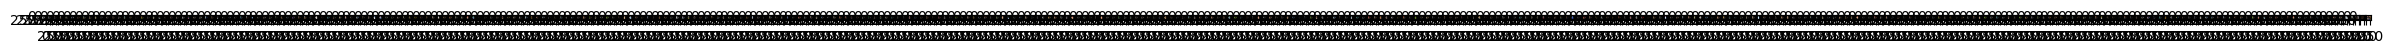

In [12]:
train_generator = train_datagen.flow_from_directory(
							train_dir,
							target_size = (300, 300),
							batch_size = 400,
							class_mode ='categorical',
							)


images , labels = train_generator[0]

print(images.shape)
print(labels)


plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, images.shape[0], figsize=(30, 4))

for i in range(images.shape[0]) :
  axarr[i].imshow(images[i])

In [13]:
path = "videogames-cnn-dataset"

train_generator = train_datagen.flow_from_directory(
							train_dir,
							target_size = (300, 300),
							batch_size = 400,
							class_mode ='categorical',
							save_to_dir= path + '/augmented',
							save_prefix='aug',
							save_format='png'
							)

Found 18586 images belonging to 3 classes.


In [ ]:
from tensorflow.keras import optimizers
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision

# 1. Activamos mixed precision para aprovechar los Tensor Cores de tu RTX 3060
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

model = models.Sequential()

# Capas intermedias (usarán float16 automáticamente)
model.add(layers.Conv2D(10, (3, 3), activation="relu", input_shape=(300, 300, 3)))
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))

# 2. Capa de salida: Es fundamental que sea float32 para evitar errores de precisión
# Nota: Usas sigmoid y binary_crossentropy para 3 clases; 
# esto sugiere que es un problema multi-etiqueta.
model.add(layers.Dense(3, activation='softmax', dtype='float32'))

model.summary()

model.compile(loss='categorical_crossentropy',
						optimizer=optimizers.RMSprop(learning_rate=2e-5),
						metrics=['acc'])


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 298, 298, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 888040)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │   227,338,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 227,339,547 (867.23 MB)

 Trainable params: 227,339,547 (867.23 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
import tensorflow as tf

print(tf.__version__)

# Listar las GPUs disponibles
gpus = tf.config.list_physical_devices('GPU')
print("GPUs disponibles:", len(gpus))

if gpus:
    for gpu in gpus:
        print(f"Nombre del dispositivo: {gpu}")
else:
    print("No se detectó ninguna GPU. Se usará la CPU.")

2.21.0
GPUs disponibles: 0
No se detectó ninguna GPU. Se usará la CPU.


In [16]:
import tensorflow as tf

# Esto debe devolver una lista con tu GPU
print("Dispositivos detectados:", tf.config.list_physical_devices())

# Esto confirma que TF puede usar la GPU para cálculos
print("¿TensorFlow puede usar la GPU?:", tf.test.is_built_with_cuda())


Dispositivos detectados: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
¿TensorFlow puede usar la GPU?: False


In [17]:
from tensorflow.keras.callbacks import ModelCheckpoint

In [18]:
# Create Tensorflow checkpoint object with epoch and batch details
checkpoint_path = "/checkpoints_Base/checkpoint.weights.h5"
checkpoint_50 = ModelCheckpoint(filepath = checkpoint_path,
                                  save_weights_only = False,
                                  save_freq = "epoch",
                                  monitor = "val_accuracy",
                                  save_best_only = True,
                                  verbose = 1)

In [19]:

history = model.fit(
						train_generator,
						epochs = 10,
						callbacks = [checkpoint_50])


acc = history.history['acc']
loss = history.history['loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs,acc,'bo',label='train accuracy')
plt.title('train acc')
plt.legend()

plt.figure()

plt.plot(epochs,loss, 'bo', label ='training loss')
plt.title('train loss')
plt.legend()

plt.show()


Epoch 1/10
24/47 ━━━━━━━━━━━━━━━━━━━━ 11:14 29s/step - acc: 0.4417 - loss: 1.4543

KeyboardInterrupt: 